In [1]:
# ============================================================
# CELL 1 — IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import os, time, logging
from itertools import product
from joblib import Parallel, delayed

# ── Statistical / Time-Series ────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm          # pip install pmdarima

# ── ML ───────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ── Prophet ──────────────────────────────────────────────────
try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    PROPHET_OK = False
    print("Prophet not installed — will be skipped.")

# ── Output dirs ──────────────────────────────────────────────
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler("outputs/execution.log"),
              logging.StreamHandler()]
)
log = logging.getLogger(__name__)

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("tab10")

RANDOM_STATE = 42
N_JOBS       = -1          # parallel cores
FORECAST_MONTHS = pd.date_range("2025-01-01", periods=3, freq="MS")
TRAIN_END   = pd.Timestamp("2024-12-01")

log.info("✅ Imports complete.")

2026-06-04 10:05:31,412 | INFO | ✅ Imports complete.


In [2]:
# ============================================================
# CELL 2 — DATA LOADING & VALIDATION
# ============================================================
RAW_PATH = "final_data_for_vehicle_forecasting.csv"   # adjust path if needed

df_raw = pd.read_csv(RAW_PATH)
df_raw.columns = df_raw.columns.str.strip()

# ── Rename to standard names ─────────────────────────────────
df_raw.rename(columns={
    "Halb":         "HALB",
    "engine_type":  "Engine",
    "map_model":    "Map_Model",
    "Vehicle_Type": "Vehicle_Type",
    "Month":        "Month",
    "total_demand": "Demand",
}, inplace=True)

df_raw["HALB"] = df_raw["HALB"].astype(str)
df_raw["Month"] = pd.to_datetime(df_raw["Month"], dayfirst=True)

# ── Validation ───────────────────────────────────────────────
print("=" * 55)
print("DATA VALIDATION REPORT")
print("=" * 55)

print(f"\nShape            : {df_raw.shape}")
print(f"Date range       : {df_raw['Month'].min().date()} → {df_raw['Month'].max().date()}")
print(f"Unique HALBs     : {df_raw['HALB'].nunique()}")
print(f"Unique Engines   : {df_raw['Engine'].nunique()}")
print(f"Unique Map Models: {df_raw['Map_Model'].nunique()}")
print(f"Unique Veh Types : {df_raw['Vehicle_Type'].nunique()}")

# Missing values
miss = df_raw.isnull().sum()
print(f"\nMissing values:\n{miss[miss > 0] if miss.any() else '  None'}")

# Duplicates
dups = df_raw.duplicated(subset=["HALB","Engine","Map_Model","Vehicle_Type","Month"]).sum()
print(f"\nDuplicate records: {dups}")
if dups:
    df_raw = df_raw.drop_duplicates(subset=["HALB","Engine","Map_Model","Vehicle_Type","Month"])
    print("  → Duplicates removed.")

# Negative demand
neg = (df_raw["Demand"] < 0).sum()
print(f"Negative demand rows: {neg}")
df_raw["Demand"] = df_raw["Demand"].clip(lower=0)

# Zero-demand ratio
zero_pct = (df_raw["Demand"] == 0).mean() * 100
print(f"Zero-demand %    : {zero_pct:.1f}%")

# Date continuity check
expected_months = pd.date_range(df_raw["Month"].min(), df_raw["Month"].max(), freq="MS")
present_months  = df_raw["Month"].unique()
missing_months  = set(expected_months) - set(present_months)
print(f"Expected months  : {len(expected_months)}")
print(f"Present months   : {len(present_months)}")
print(f"Missing months   : {missing_months if missing_months else 'None'}")

print("\n✅ Validation complete — dataset ready.")

DATA VALIDATION REPORT

Shape            : (49680, 6)
Date range       : 2023-04-01 → 2025-03-01
Unique HALBs     : 1772
Unique Engines   : 49
Unique Map Models: 330
Unique Veh Types : 3

Missing values:
  None

Duplicate records: 0
Negative demand rows: 0
Zero-demand %    : 83.8%
Expected months  : 24
Present months   : 24
Missing months   : None

✅ Validation complete — dataset ready.


2026-06-04 10:06:07,314 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 10:06:07,317 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


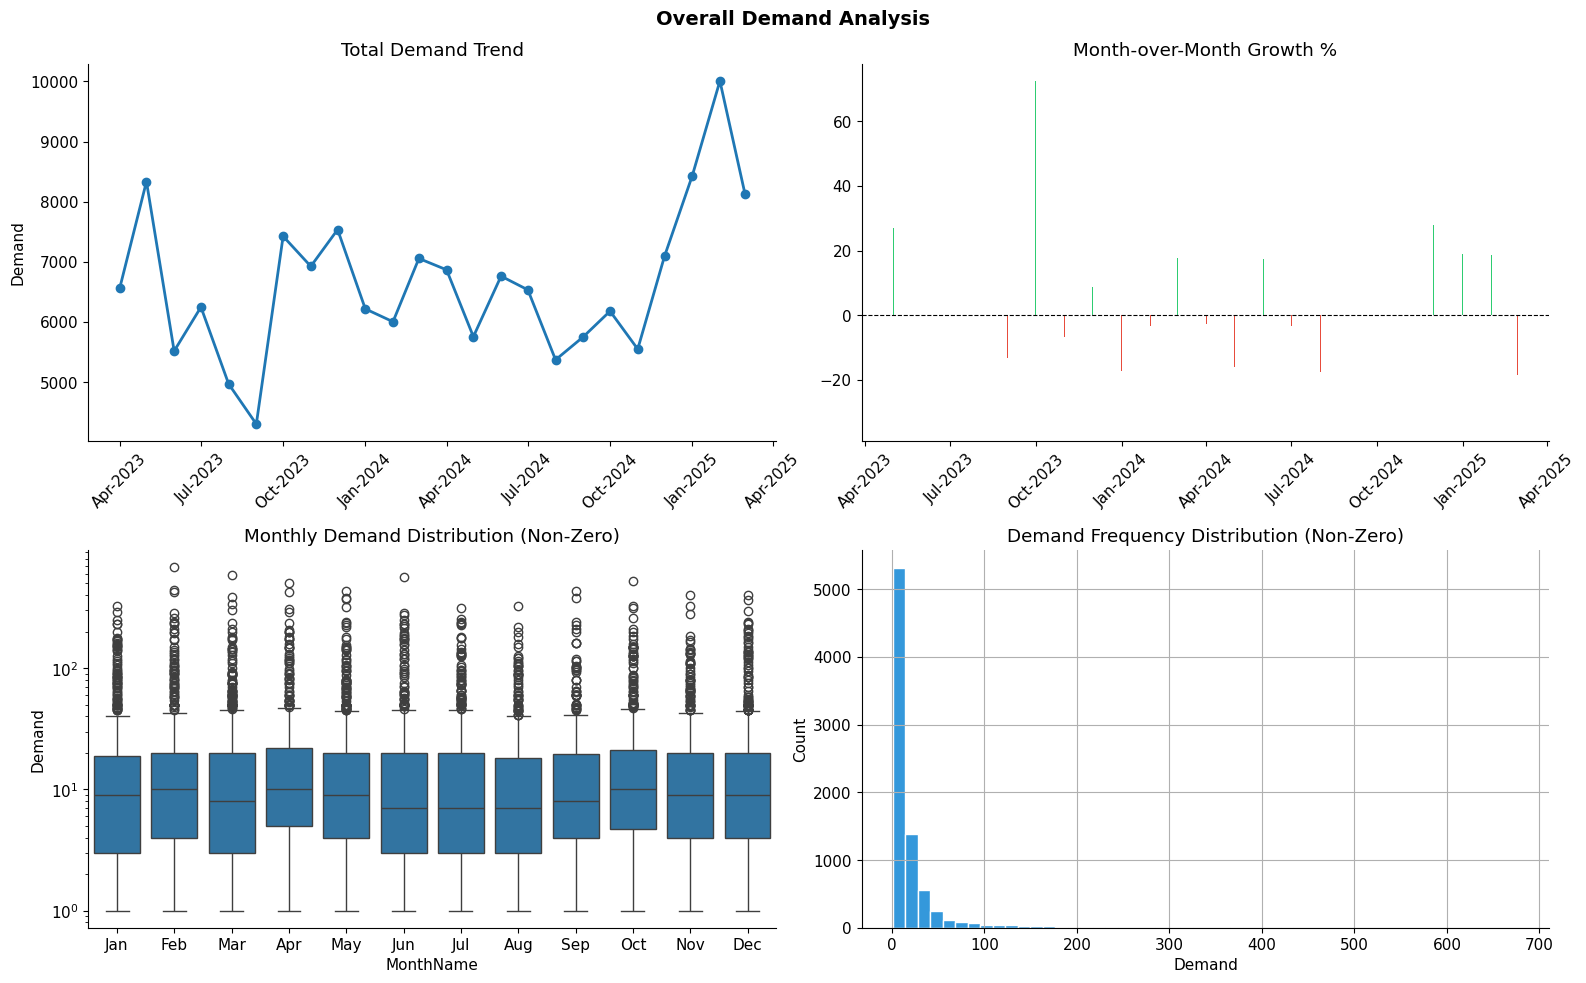

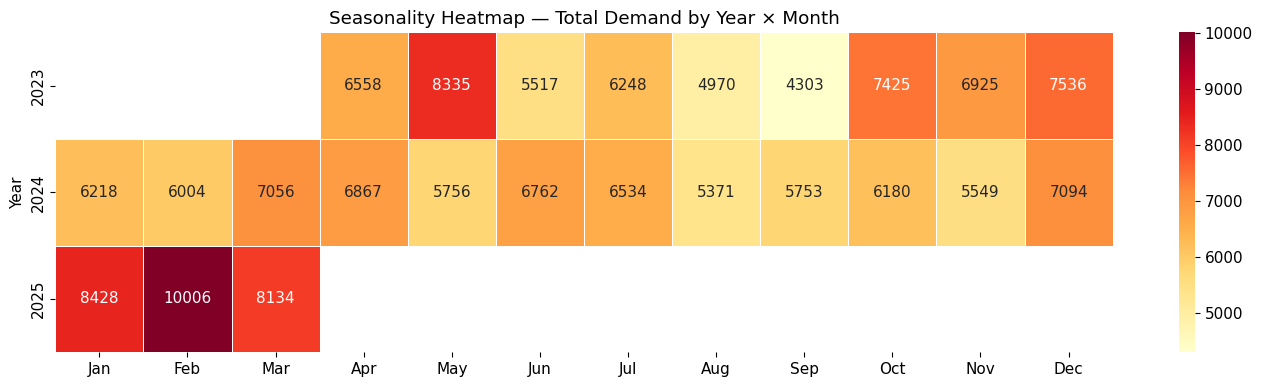


Monthly demand summary:
            Demand  MoM_Growth
Month                         
2023-04-01    6558         NaN
2023-05-01    8335   27.096676
2023-06-01    5517  -33.809238
2023-07-01    6248   13.249955
2023-08-01    4970  -20.454545
2023-09-01    4303  -13.420523
2023-10-01    7425   72.554032
2023-11-01    6925   -6.734007
2023-12-01    7536    8.823105
2024-01-01    6218  -17.489384
2024-02-01    6004   -3.441621
2024-03-01    7056   17.521652
2024-04-01    6867   -2.678571
2024-05-01    5756  -16.178826
2024-06-01    6762   17.477415
2024-07-01    6534   -3.371783
2024-08-01    5371  -17.799204
2024-09-01    5753    7.112270
2024-10-01    6180    7.422214
2024-11-01    5549  -10.210356
2024-12-01    7094   27.842855
2025-01-01    8428   18.804624
2025-02-01   10006   18.723303
2025-03-01    8134  -18.708775


In [3]:
# ============================================================
# CELL 3 — EDA: OVERALL DEMAND ANALYSIS
# ============================================================
df = df_raw.copy()

# ── 1. Total demand over time ────────────────────────────────
monthly_total = df.groupby("Month")["Demand"].sum().reset_index()
monthly_total["MoM_Growth"] = monthly_total["Demand"].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Overall Demand Analysis", fontsize=14, fontweight="bold")

# Total trend
axes[0,0].plot(monthly_total["Month"], monthly_total["Demand"], marker="o", linewidth=2)
axes[0,0].set_title("Total Demand Trend")
axes[0,0].set_ylabel("Demand")
axes[0,0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b-%Y"))
plt.setp(axes[0,0].get_xticklabels(), rotation=45)

# MoM Growth
axes[0,1].bar(monthly_total["Month"], monthly_total["MoM_Growth"],
              color=["#2ecc71" if x >= 0 else "#e74c3c" for x in monthly_total["MoM_Growth"]])
axes[0,1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0,1].set_title("Month-over-Month Growth %")
axes[0,1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b-%Y"))
plt.setp(axes[0,1].get_xticklabels(), rotation=45)

# Monthly distribution (boxplot by calendar month)
df["CalMonth"] = df["Month"].dt.month
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["MonthName"] = df["CalMonth"].map(month_names)
order = [month_names[i] for i in range(1, 13)]
df_nonzero = df[df["Demand"] > 0]
sns.boxplot(data=df_nonzero, x="MonthName", y="Demand", order=order, ax=axes[1,0])
axes[1,0].set_title("Monthly Demand Distribution (Non-Zero)")
axes[1,0].set_yscale("log")

# Demand histogram
df_nonzero["Demand"].hist(bins=50, ax=axes[1,1], color="#3498db", edgecolor="white")
axes[1,1].set_title("Demand Frequency Distribution (Non-Zero)")
axes[1,1].set_xlabel("Demand")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("outputs/plots/01_overall_demand.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Seasonality heatmap ──────────────────────────────────────
df["Year"] = df["Month"].dt.year
pivot = df.groupby(["Year","CalMonth"])["Demand"].sum().unstack()
pivot.columns = [month_names[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Seasonality Heatmap — Total Demand by Year × Month")
plt.tight_layout()
plt.savefig("outputs/plots/02_seasonality_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMonthly demand summary:")
print(monthly_total.set_index("Month")[["Demand","MoM_Growth"]].to_string())

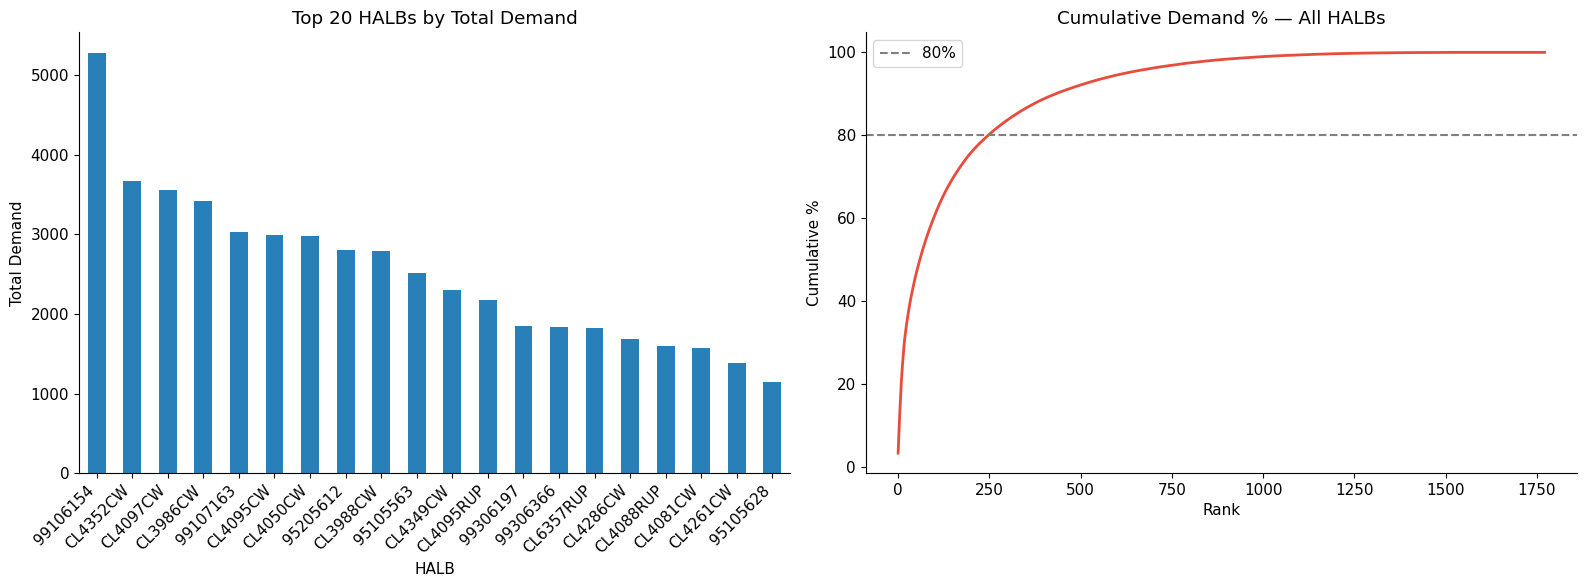

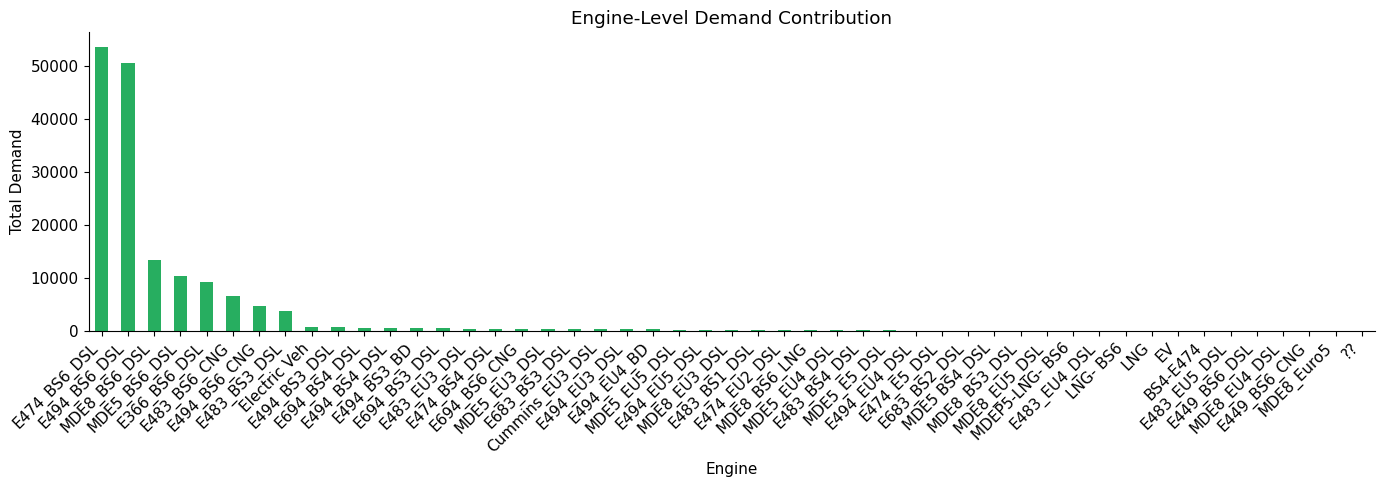

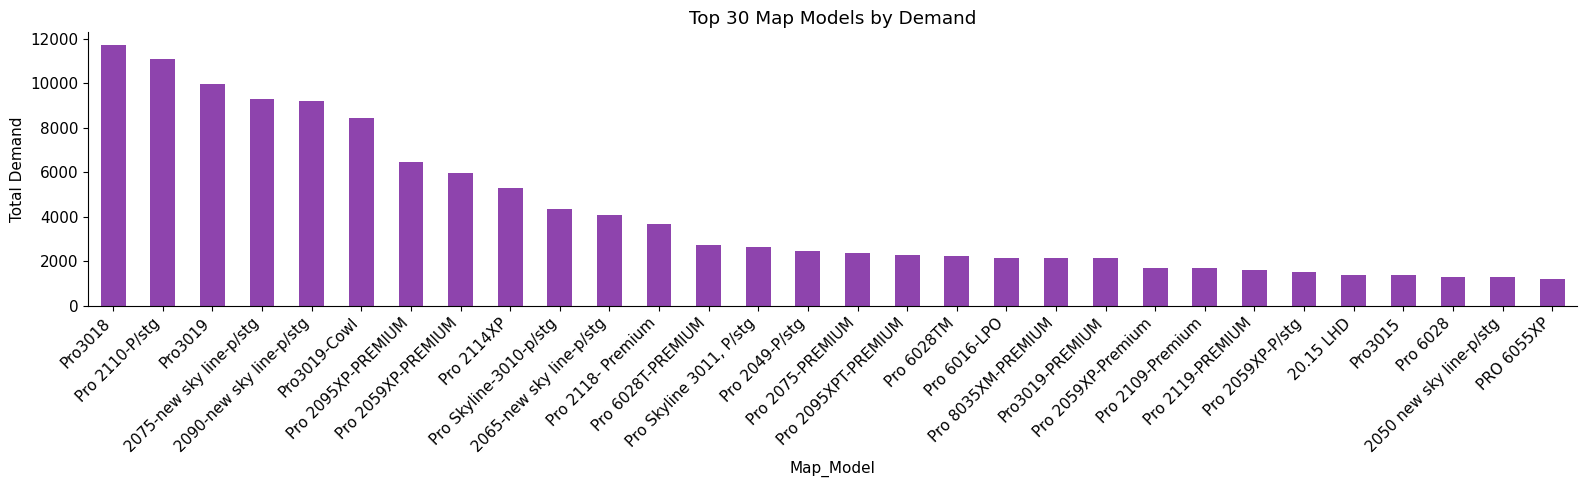

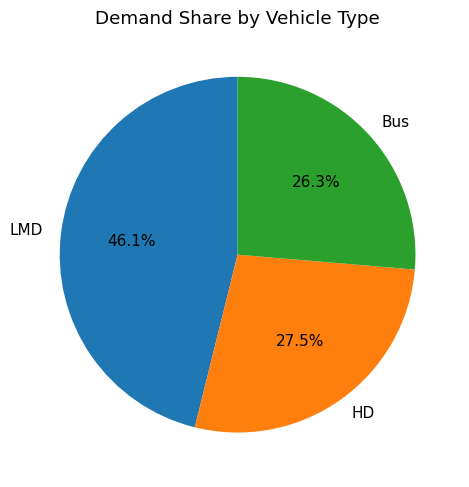

Hierarchy summary saved.


In [4]:
# ============================================================
# CELL 4 — EDA: HIERARCHICAL ANALYSIS
# ============================================================

# ── HALB level ───────────────────────────────────────────────
halb_demand = df.groupby("HALB")["Demand"].sum().sort_values(ascending=False)
total_demand = halb_demand.sum()
halb_pct     = (halb_demand / total_demand * 100).cumsum()

top_halb = halb_demand.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_halb.plot(kind="bar", ax=axes[0], color="#2980b9")
axes[0].set_title("Top 20 HALBs by Total Demand")
axes[0].set_ylabel("Total Demand")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

axes[1].plot(halb_pct.values, linewidth=2, color="#e74c3c")
axes[1].axhline(80, color="gray", linestyle="--", label="80%")
axes[1].set_title("Cumulative Demand % — All HALBs")
axes[1].set_ylabel("Cumulative %")
axes[1].set_xlabel("Rank")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/plots/03_halb_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Engine level ─────────────────────────────────────────────
eng_demand = df.groupby("Engine")["Demand"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
eng_demand.plot(kind="bar", ax=ax, color="#27ae60")
ax.set_title("Engine-Level Demand Contribution")
ax.set_ylabel("Total Demand")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/plots/04_engine_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Map Model level ──────────────────────────────────────────
model_demand = df.groupby("Map_Model")["Demand"].sum().sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(16, 5))
model_demand.plot(kind="bar", ax=ax, color="#8e44ad")
ax.set_title("Top 30 Map Models by Demand")
ax.set_ylabel("Total Demand")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/plots/05_mapmodel_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Vehicle Type level ───────────────────────────────────────
vt_demand = df.groupby("Vehicle_Type")["Demand"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
vt_demand.plot(kind="pie", ax=ax, autopct="%1.1f%%", startangle=90)
ax.set_title("Demand Share by Vehicle Type")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("outputs/plots/06_vehicletype_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Hierarchy summary saved.")

Train rows : 43470  (2023-04-01 → 2024-12-01)
Test rows  : 6210   (2025-01-01 → 2025-03-01)

Classifying demand patterns for all leaf segments…
  Done in 0.7s — 2,070 segments

Demand type distribution:
Demand_Type
Lumpy           784
Intermittent    671
Zero            615
Name: count, dtype: int64


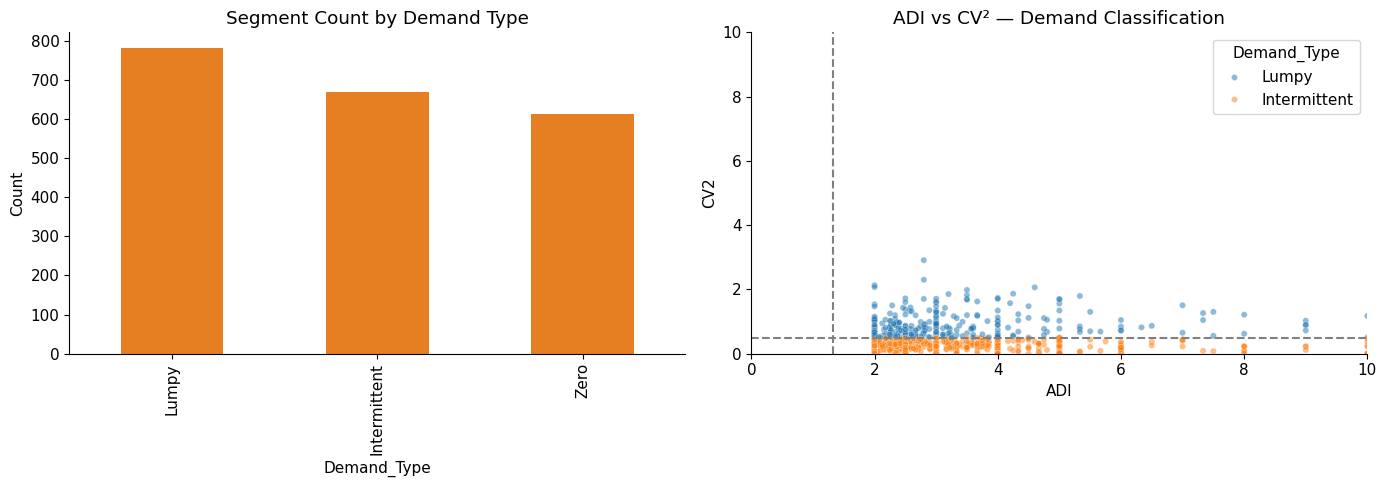

In [5]:
# ============================================================
# CELL 5 — SEGMENTATION & DEMAND PATTERN CLASSIFICATION
# ============================================================

KEY_COLS  = ["HALB", "Engine", "Map_Model", "Vehicle_Type"]
GRP_COLS  = KEY_COLS + ["Month"]

# ── Split train / test ───────────────────────────────────────
df_train = df[df["Month"] <= TRAIN_END].copy()
df_test  = df[df["Month"].isin(FORECAST_MONTHS)].copy()

print(f"Train rows : {len(df_train)}  ({df_train['Month'].min().date()} → {df_train['Month'].max().date()})")
print(f"Test rows  : {len(df_test)}   ({df_test['Month'].min().date()} → {df_test['Month'].max().date()})")

# ── Build segment-level series ───────────────────────────────
def build_series(data, keys):
    grp = data.groupby(keys + ["Month"])["Demand"].sum().reset_index()
    return grp

seg_leaf = build_series(df_train, KEY_COLS)

# ── Demand classification (ADI + CV²) ────────────────────────
def classify_demand(series: pd.Series):
    """Classify demand as Smooth / Erratic / Intermittent / Lumpy."""
    n = len(series)
    nonzero = series[series > 0]
    if len(nonzero) == 0:
        return "Zero", np.nan, np.nan
    # ADI: avg inter-demand interval
    nz_idx = np.where(series > 0)[0]
    if len(nz_idx) > 1:
        adi = np.mean(np.diff(nz_idx)) + 1
    else:
        adi = n  # single demand event
    cv2 = (nonzero.std() / nonzero.mean()) ** 2 if nonzero.mean() > 0 else 0
    if adi <= 1.32 and cv2 <= 0.49:
        dtype = "Smooth"
    elif adi <= 1.32 and cv2 > 0.49:
        dtype = "Erratic"
    elif adi > 1.32 and cv2 <= 0.49:
        dtype = "Intermittent"
    else:
        dtype = "Lumpy"
    return dtype, round(adi, 3), round(cv2, 3)

print("\nClassifying demand patterns for all leaf segments…")
t0 = time.time()

segment_stats = []
for keys, grp in seg_leaf.groupby(KEY_COLS):
    s = grp.set_index("Month")["Demand"].sort_index()
    full_idx = pd.date_range(s.index.min(), TRAIN_END, freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    dtype, adi, cv2 = classify_demand(s)
    segment_stats.append({
        "HALB": keys[0], "Engine": keys[1],
        "Map_Model": keys[2], "Vehicle_Type": keys[3],
        "n_months": len(s),
        "total_demand": s.sum(),
        "nonzero_months": (s > 0).sum(),
        "zero_pct": (s == 0).mean() * 100,
        "mean_demand": s.mean(),
        "std_demand": s.std(),
        "ADI": adi, "CV2": cv2,
        "Demand_Type": dtype,
    })

seg_stats_df = pd.DataFrame(segment_stats)
seg_stats_df.to_csv("outputs/segment_stats.csv", index=False)
print(f"  Done in {time.time()-t0:.1f}s — {len(seg_stats_df):,} segments")
print("\nDemand type distribution:")
print(seg_stats_df["Demand_Type"].value_counts())

# ── Visualise demand type distribution ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_stats_df["Demand_Type"].value_counts().plot(kind="bar", ax=axes[0], color="#e67e22")
axes[0].set_title("Segment Count by Demand Type")
axes[0].set_ylabel("Count")

sns.scatterplot(data=seg_stats_df[seg_stats_df["ADI"].notna()],
                x="ADI", y="CV2", hue="Demand_Type",
                alpha=0.5, s=20, ax=axes[1])
axes[1].axvline(1.32, color="gray", linestyle="--")
axes[1].axhline(0.49, color="gray", linestyle="--")
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)
axes[1].set_title("ADI vs CV² — Demand Classification")

plt.tight_layout()
plt.savefig("outputs/plots/07_demand_classification.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# CELL 6 — FEATURE ENGINEERING HELPERS
# ============================================================

def make_features(series: pd.Series) -> pd.DataFrame:
    """
    Given a monthly demand series (DatetimeIndex), return a
    feature DataFrame for ML models.
    """
    df_f = pd.DataFrame({"Demand": series})
    df_f["Year"]        = df_f.index.year
    df_f["Quarter"]     = df_f.index.quarter
    df_f["Month_num"]   = df_f.index.month
    df_f["Month_sin"]   = np.sin(2 * np.pi * df_f.index.month / 12)
    df_f["Month_cos"]   = np.cos(2 * np.pi * df_f.index.month / 12)

    for lag in [1, 2, 3, 6, 12]:
        df_f[f"Lag_{lag}"] = df_f["Demand"].shift(lag)

    for w in [3, 6]:
        df_f[f"Roll_Mean_{w}"] = df_f["Demand"].shift(1).rolling(w).mean()
        df_f[f"Roll_Std_{w}"]  = df_f["Demand"].shift(1).rolling(w).std()

    df_f["Demand_Growth"]   = df_f["Demand"].pct_change().replace([np.inf, -np.inf], 0)
    df_f["Demand_Momentum"] = df_f["Demand"] - df_f["Demand"].shift(1)
    df_f["Zero_Flag"]       = (df_f["Demand"] == 0).astype(int)
    return df_f


def make_future_features(last_series: pd.Series,
                          forecast_months: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Build feature rows for forecast months (lags from training tail).
    """
    rows = []
    extended = last_series.copy()
    for fmonth in forecast_months:
        row = {
            "Year":      fmonth.year,
            "Quarter":   fmonth.quarter,
            "Month_num": fmonth.month,
            "Month_sin": np.sin(2 * np.pi * fmonth.month / 12),
            "Month_cos": np.cos(2 * np.pi * fmonth.month / 12),
        }
        for lag in [1, 2, 3, 6, 12]:
            idx = len(extended) - lag
            row[f"Lag_{lag}"] = extended.iloc[idx] if idx >= 0 else 0
        for w in [3, 6]:
            tail = extended.iloc[-w:] if len(extended) >= w else extended
            row[f"Roll_Mean_{w}"] = tail.mean()
            row[f"Roll_Std_{w}"]  = tail.std() if len(tail) > 1 else 0
        prev = extended.iloc[-1] if len(extended) > 0 else 0
        prev2 = extended.iloc[-2] if len(extended) > 1 else 0
        row["Demand_Growth"]   = (prev - prev2) / prev2 if prev2 != 0 else 0
        row["Demand_Momentum"] = prev - prev2
        row["Zero_Flag"]       = int(prev == 0)
        rows.append(row)
        extended = pd.concat([extended,
                              pd.Series([0], index=[fmonth])])  # placeholder
    return pd.DataFrame(rows, index=forecast_months)


FEAT_COLS = (
    ["Year","Quarter","Month_num","Month_sin","Month_cos"] +
    [f"Lag_{l}" for l in [1,2,3,6,12]] +
    [f"Roll_Mean_{w}" for w in [3,6]] +
    [f"Roll_Std_{w}"  for w in [3,6]] +
    ["Demand_Growth","Demand_Momentum","Zero_Flag"]
)

print("✅ Feature engineering helpers defined.")

✅ Feature engineering helpers defined.


✅ Model registry ready — 25 models loaded.


In [8]:
# ============================================================
# CELL 8 — METRICS HELPERS
# ============================================================

def compute_metrics(actual: np.ndarray, forecast: np.ndarray) -> dict:
    """
    Return full metric suite with zero / non-zero split.
    All inputs should be 1-D arrays of the same length.
    """
    actual   = np.asarray(actual,   dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    forecast = np.clip(forecast, 0, None)

    n = len(actual)
    mask_zero    = actual == 0
    mask_nonzero = actual >  0

    # ── Overall ────────────────────────────────────────────
    mae  = mean_absolute_error(actual, forecast) if n else np.nan
    rmse = np.sqrt(mean_squared_error(actual, forecast)) if n else np.nan

    nonzero_actual = actual[mask_nonzero]
    if len(nonzero_actual) > 0:
        mape  = np.mean(np.abs((nonzero_actual - forecast[mask_nonzero]) / nonzero_actual)) * 100
        smape = np.mean(2 * np.abs(actual[mask_nonzero] - forecast[mask_nonzero]) /
                        (np.abs(actual[mask_nonzero]) + np.abs(forecast[mask_nonzero]) + 1e-8)) * 100
    else:
        mape = smape = np.nan

    wmape_denom = actual.sum()
    wmape = (np.abs(actual - forecast).sum() / wmape_denom * 100) if wmape_denom > 0 else np.nan
    r2    = r2_score(actual, forecast) if n > 1 else np.nan
    acc   = max(0, 100 - wmape) if not np.isnan(wmape) else np.nan

    # ── Zero cases ─────────────────────────────────────────
    if mask_zero.sum() > 0:
        # How often did we predict ~0 when actual is 0
        zero_preds = forecast[mask_zero]
        zero_det_rate = (zero_preds < 0.5).mean() * 100
        false_pos_rate = (zero_preds >= 0.5).mean() * 100
        mae_zero  = mean_absolute_error(actual[mask_zero], zero_preds)
        rmse_zero = np.sqrt(mean_squared_error(actual[mask_zero], zero_preds))
        acc_zero  = max(0, 100 - mae_zero / (actual.mean() + 1e-8) * 100)
    else:
        zero_det_rate = false_pos_rate = mae_zero = rmse_zero = acc_zero = np.nan

    # ── Non-zero cases ─────────────────────────────────────
    if mask_nonzero.sum() > 0:
        mae_nz  = mean_absolute_error(actual[mask_nonzero], forecast[mask_nonzero])
        rmse_nz = np.sqrt(mean_squared_error(actual[mask_nonzero], forecast[mask_nonzero]))
        acc_nz  = max(0, 100 - mape) if not np.isnan(mape) else np.nan
    else:
        mae_nz = rmse_nz = acc_nz = np.nan

    return {
        "MAE": round(mae, 4),  "RMSE": round(rmse, 4),
        "MAPE": round(mape, 2) if not np.isnan(mape) else np.nan,
        "sMAPE": round(smape, 2) if not np.isnan(smape) else np.nan,
        "WMAPE": round(wmape, 2) if not np.isnan(wmape) else np.nan,
        "R2":   round(r2, 4)   if not np.isnan(r2)   else np.nan,
        "Accuracy":         round(acc, 2)   if not np.isnan(acc)   else np.nan,
        "MAE_Zero":         round(mae_zero, 4)  if not np.isnan(mae_zero)  else np.nan,
        "RMSE_Zero":        round(rmse_zero, 4) if not np.isnan(rmse_zero) else np.nan,
        "Accuracy_Zero":    round(acc_zero, 2)  if not np.isnan(acc_zero)  else np.nan,
        "Zero_Detection_Rate":  round(zero_det_rate, 2)  if not np.isnan(zero_det_rate)  else np.nan,
        "False_Positive_Rate":  round(false_pos_rate, 2) if not np.isnan(false_pos_rate) else np.nan,
        "MAE_NonZero":      round(mae_nz, 4) if not np.isnan(mae_nz) else np.nan,
        "RMSE_NonZero":     round(rmse_nz, 4) if not np.isnan(rmse_nz) else np.nan,
        "Accuracy_NonZero": round(acc_nz, 2)  if not np.isnan(acc_nz)  else np.nan,
    }


print("✅ Metrics helpers defined.")

✅ Metrics helpers defined.


In [13]:
# ============================================================
# CELL 9 — CORE FORECASTING LOOP  (Parallel per segment)
# ============================================================

def forecast_one_segment(row_keys, train_grp, test_grp):
    halb, engine, map_model, vtype = row_keys

    full_idx = pd.date_range("2023-04-01", TRAIN_END, freq="MS")
    s = (train_grp.set_index("Month")["Demand"]
                  .reindex(full_idx, fill_value=0)
                  .astype(float))

    # ── SKIP dead segments ────────────────────────────────────
    nonzero_pct = (s > 0).mean()
    total_demand = s.sum()
    if total_demand == 0:
        actuals = np.array([test_grp.set_index("Month")["Demand"].get(m, 0) 
                            for m in FORECAST_MONTHS]) if len(test_grp) else np.zeros(3)
        results = []
        for i, month in enumerate(FORECAST_MONTHS):
            results.append({
                "HALB": halb, "Engine": engine,
                "Map_Model": map_model, "Vehicle_Type": vtype,
                "Month": month, "Actual_Demand": actuals[i],
                "Forecast": 0.0, "Model": "Zero_Forecast",
                **compute_metrics(actuals, np.zeros(3)),
            })
        return results

    # ── Use only active window (trim leading zeros) ───────────
    first_nonzero = s[s > 0].index.min()
    s = s[s.index >= first_nonzero]

    # ── EVERYTHING BELOW IS UNCHANGED FROM ORIGINAL ──────────

    if len(test_grp):
        actual_dict = test_grp.set_index("Month")["Demand"].to_dict()
    else:
        actual_dict = {}
    actuals = np.array([actual_dict.get(m, 0) for m in FORECAST_MONTHS])

    results = []
    for model_name, model_fn in MODEL_REGISTRY.items():
        preds = _safe_forecast(model_fn, s)
        if preds is None:
            continue
        preds = np.clip(preds, 0, None)

        metrics = compute_metrics(actuals, preds)
        for i, month in enumerate(FORECAST_MONTHS):
            results.append({
                "HALB":         halb,
                "Engine":       engine,
                "Map_Model":    map_model,
                "Vehicle_Type": vtype,
                "Month":        month,
                "Actual_Demand": actuals[i],
                "Forecast":     round(preds[i], 4),
                "Model":        model_name,
                **{k: metrics[k] for k in metrics},
            })
    return results


# ── Prepare per-segment data ─────────────────────────────────
segments = df_train.groupby(KEY_COLS)
test_segments = df_test.groupby(KEY_COLS) if len(df_test) > 0 else {}

seg_keys = list(segments.groups.keys())
print(f"Total leaf segments to forecast: {len(seg_keys):,}")

test_lookup = {}
for keys, grp in df_test.groupby(KEY_COLS):
    test_lookup[keys] = grp.reset_index(drop=True)

# ── Run in parallel ──────────────────────────────────────────
print("Starting parallel forecasting… (this may take several minutes)")
t0 = time.time()

all_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=5)(
    delayed(forecast_one_segment)(
        keys,
        segments.get_group(keys).reset_index(drop=True),
        test_lookup.get(keys, pd.DataFrame(columns=["Month","Demand"]))
    )
    for keys in seg_keys
)

flat_results = [r for seg in all_results for r in seg]
results_df = pd.DataFrame(flat_results)

elapsed = time.time() - t0
print(f"\n✅ Forecasting complete — {len(results_df):,} rows in {elapsed:.1f}s")
results_df.to_csv("outputs/forecast_details_leaf.csv", index=False)
print("Saved: outputs/forecast_details_leaf.csv")

Total leaf segments to forecast: 2,070
Starting parallel forecasting… (this may take several minutes)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/utkarshraj/Desktop/Internship/Vehicle Demand Forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/utkarshraj/Desktop/Internship/Vehicle Demand Forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/utkarshraj/Desktop/Internship/Vehicle Demand Forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal A


✅ Forecasting complete — 54,117 rows in 618.5s
Saved: outputs/forecast_details_leaf.csv


In [14]:
    # ============================================================
# CELL 10 — MODEL SELECTION
# ============================================================

PRIORITY_METRICS = ["Accuracy_NonZero", "WMAPE", "RMSE", "Accuracy_Zero"]

def select_best_model(grp_df):
    """
    Given all model results for one segment, pick the best model
    using priority ranking: Accuracy_NonZero (↑) > WMAPE (↓) > RMSE (↓).
    """
    model_perf = (grp_df.groupby("Model")
                        .agg({"Accuracy_NonZero":"mean",
                              "WMAPE":"mean",
                              "RMSE":"mean",
                              "Accuracy_Zero":"mean",
                              "Accuracy":"mean"})
                        .reset_index())
    # Handle NaN — treat NaN NonZero accuracy as 0
    model_perf["Accuracy_NonZero"] = model_perf["Accuracy_NonZero"].fillna(0)
    model_perf["WMAPE"]            = model_perf["WMAPE"].fillna(999)
    model_perf["RMSE"]             = model_perf["RMSE"].fillna(999)

    model_perf = model_perf.sort_values(
        ["Accuracy_NonZero","WMAPE","RMSE"],
        ascending=[False, True, True]
    )
    best = model_perf.iloc[0]["Model"]
    return best, model_perf


# ── Best model per leaf segment ───────────────────────────────
print("Selecting best model per leaf segment…")
best_model_records = []

for keys, grp in results_df.groupby(KEY_COLS):
    best, _ = select_best_model(grp)
    best_model_records.append({
        "HALB": keys[0], "Engine": keys[1],
        "Map_Model": keys[2], "Vehicle_Type": keys[3],
        "Best_Model": best,
    })

best_model_df = pd.DataFrame(best_model_records)
best_model_df.to_csv("outputs/best_model_mapping.csv", index=False)
print(f"✅ Best model mapping saved — {len(best_model_df):,} segments")
print("\nBest model frequency:")
print(best_model_df["Best_Model"].value_counts().head(10))

Selecting best model per leaf segment…
✅ Best model mapping saved — 2,070 segments

Best model frequency:
Best_Model
Zero_Forecast     615
ARIMA             530
Auto_ARIMA        147
Moving_Average    128
SBA               113
Holt              107
Croston            97
Weighted_MA        79
SARIMA             45
Prophet            42
Name: count, dtype: int64


In [11]:
# ============================================================
# CELL 11 — HIERARCHICAL ROLLUP
# ============================================================

# Attach best-model flag
results_merged = results_df.merge(best_model_df, on=KEY_COLS, how="left")
results_merged["Is_Best"] = results_merged["Model"] == results_merged["Best_Model"]

# Filter to best-model forecasts only for rollup
best_forecasts = results_merged[results_merged["Is_Best"]].copy()

def rollup_forecast(df_in, group_cols):
    """Aggregate leaf forecasts to a higher hierarchy level."""
    return (df_in.groupby(group_cols + ["Month"])
                 .agg(Actual_Demand=("Actual_Demand","sum"),
                      Forecast=("Forecast","sum"))
                 .reset_index())


rollup_vt     = rollup_forecast(best_forecasts, KEY_COLS)                     # leaf
rollup_model  = rollup_forecast(best_forecasts, ["HALB","Engine","Map_Model"])
rollup_engine = rollup_forecast(best_forecasts, ["HALB","Engine"])
rollup_halb   = rollup_forecast(best_forecasts, ["HALB"])

print("Rollup shapes:")
print(f"  Leaf (HALB+Eng+Model+VType): {rollup_vt.shape}")
print(f"  Map Model level            : {rollup_model.shape}")
print(f"  Engine level               : {rollup_engine.shape}")
print(f"  HALB level                 : {rollup_halb.shape}")

# Save rollups
rollup_vt.to_csv("outputs/rollup_vehicletype.csv", index=False)
rollup_model.to_csv("outputs/rollup_mapmodel.csv", index=False)
rollup_engine.to_csv("outputs/rollup_engine.csv", index=False)
rollup_halb.to_csv("outputs/rollup_halb.csv", index=False)
print("✅ Rollup CSVs saved.")

Rollup shapes:
  Leaf (HALB+Eng+Model+VType): (6210, 7)
  Map Model level            : (6138, 6)
  Engine level               : (5487, 5)
  HALB level                 : (5316, 4)
✅ Rollup CSVs saved.


In [15]:
# ============================================================
# CELL 12 — MODEL PERFORMANCE SUMMARY
# ============================================================

perf_summary = (
    results_df.groupby("Model")
    .agg(
        MAE=("MAE","mean"),
        RMSE=("RMSE","mean"),
        MAPE=("MAPE","mean"),
        WMAPE=("WMAPE","mean"),
        Accuracy=("Accuracy","mean"),
        Accuracy_Zero=("Accuracy_Zero","mean"),
        Accuracy_NonZero=("Accuracy_NonZero","mean"),
        Segments=("Model","count"),
    )
    .reset_index()
    .sort_values("Accuracy_NonZero", ascending=False)
)

print("=" * 70)
print("MODEL PERFORMANCE SUMMARY (mean across all segments)")
print("=" * 70)
print(perf_summary.to_string(index=False))

perf_summary.to_csv("outputs/model_performance_summary.csv", index=False)
print("\n✅ Saved: outputs/model_performance_summary.csv")

# ── Overall best model ────────────────────────────────────────
overall_best = perf_summary.iloc[0]["Model"]
print(f"\n🏆 Overall Best Model: {overall_best}")

# ── Best model per hierarchy ──────────────────────────────────
def best_model_at_level(df_in, group_cols):
    rows = []
    for keys, grp in df_in.groupby(group_cols):
        best, _ = select_best_model(grp)
        rec = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        rec["Best_Model"] = best
        rows.append(rec)
    return pd.DataFrame(rows)

best_per_halb    = best_model_at_level(results_df, ["HALB"])
best_per_engine  = best_model_at_level(results_df, ["HALB","Engine"])
best_per_model   = best_model_at_level(results_df, ["HALB","Engine","Map_Model"])

best_per_halb.to_csv("outputs/best_model_per_halb.csv", index=False)
best_per_engine.to_csv("outputs/best_model_per_engine.csv", index=False)
best_per_model.to_csv("outputs/best_model_per_mapmodel.csv", index=False)
print("✅ Hierarchy-level best model files saved.")

MODEL PERFORMANCE SUMMARY (mean across all segments)
            Model        MAE       RMSE        MAPE       WMAPE  Accuracy  Accuracy_Zero  Accuracy_NonZero  Segments
         CatBoost  11.901079  13.659459  105.054859  172.099577 36.271338      10.013733         43.646972       480
         LightGBM  12.029756  13.720759  106.170775  165.938169 35.357042       8.426933         42.830986       480
    Random_Forest  12.210019  13.909915  111.965563  182.927254 34.715282       8.381867         41.594155       480
              SBA   8.747952   9.325619   97.344946  191.926141 20.042138       5.774292         39.918043      4365
          Croston   9.039764   9.615278  100.534058  199.456359 20.066975       5.405130         39.898333      4365
              GBR  13.384029  15.446517  129.443944  222.554648 31.781268      13.410533         38.900986       480
              TSB   4.775948   5.359110   89.178496  157.383370 20.719076       7.766095         38.787880      4365
         Ad

Total segments     : 2,070
Active segments    : 721
Inactive segments  : 1,349

MODEL PERFORMANCE — ACTIVE SEGMENTS ONLY (≥3 non-zero months)
            Model        MAE        RMSE        MAPE       WMAPE  Accuracy  Accuracy_Zero  Accuracy_NonZero  Segments
         CatBoost  11.901079   13.659459  105.054859  172.099577 36.271338      10.013733         43.646972       480
         LightGBM  12.029756   13.720759  106.170775  165.938169 35.357042       8.426933         42.830986       480
    Random_Forest  12.210019   13.909915  111.965563  182.927254 34.715282       8.381867         41.594155       480
              TSB   7.762389    8.756167   84.390711  140.222156 24.042477      10.244936         41.402477      2163
              SBA  10.320480   11.323072   86.736261  144.787179 23.260872      10.200328         40.976216      2163
          Croston  10.552977   11.553123   89.364839  149.774977 23.324748       9.543097         40.890161      2163
              SES   6.790570    

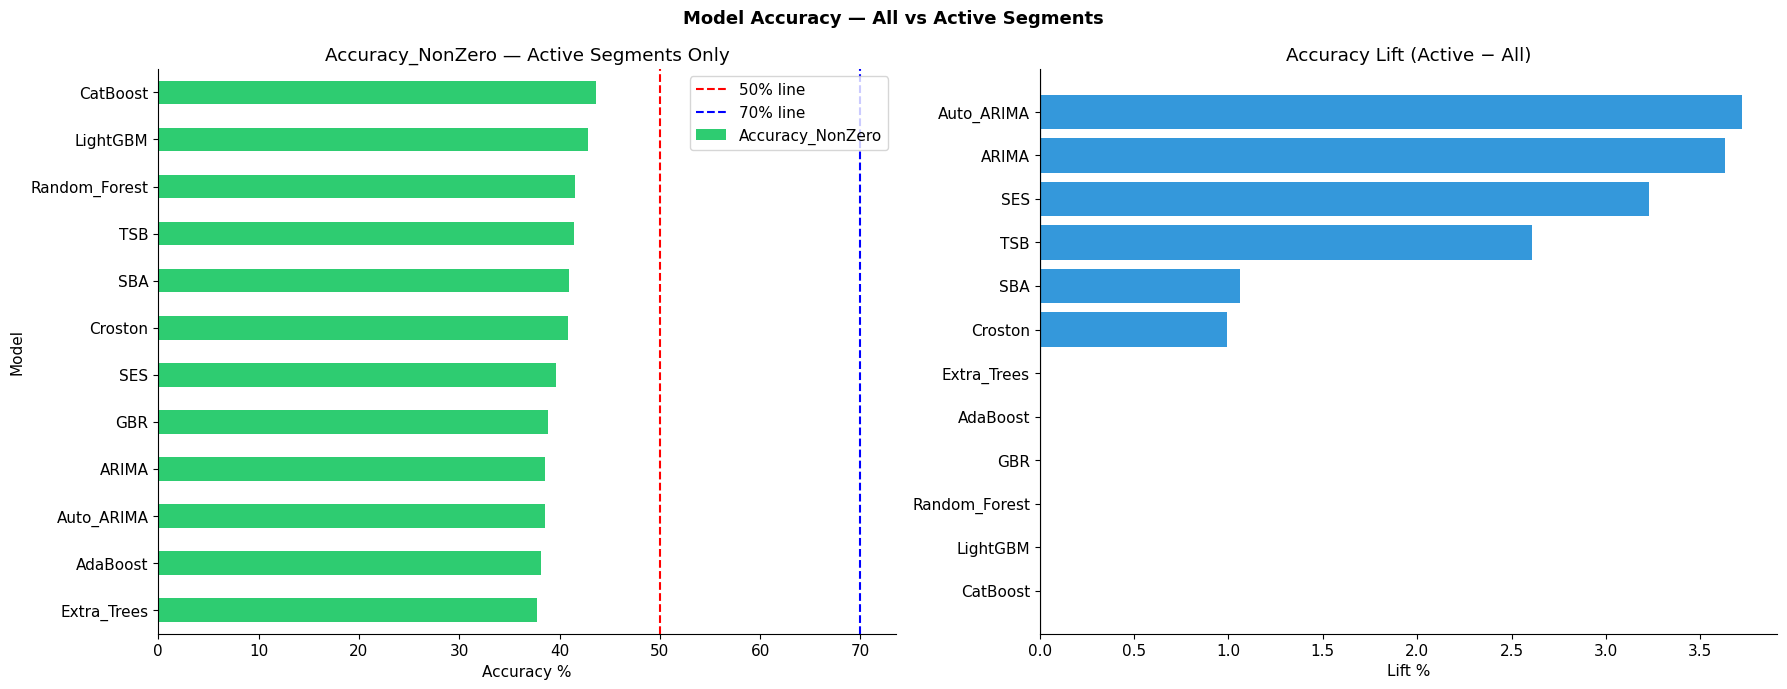

In [16]:
# ============================================================
# CELL 12B — PERFORMANCE ON ACTIVE SEGMENTS ONLY
# ============================================================

# ── Define active segments (≥3 non-zero months in training) ──
active_segs_set = set(
    seg_stats_df[seg_stats_df["nonzero_months"] >= 3]
    .apply(lambda r: (r["HALB"], r["Engine"], r["Map_Model"], r["Vehicle_Type"]), axis=1)
)

# ── Tag each result row ───────────────────────────────────────
results_df["Is_Active"] = results_df.apply(
    lambda r: (r["HALB"], r["Engine"], r["Map_Model"], r["Vehicle_Type"]) in active_segs_set,
    axis=1
)

print(f"Total segments     : {results_df[KEY_COLS].drop_duplicates().shape[0]:,}")
print(f"Active segments    : {len(active_segs_set):,}")
print(f"Inactive segments  : {results_df[KEY_COLS].drop_duplicates().shape[0] - len(active_segs_set):,}")

# ── Performance on active segments only ──────────────────────
perf_active = (
    results_df[results_df["Is_Active"]]
    .groupby("Model")
    .agg(
        MAE              = ("MAE",              "mean"),
        RMSE             = ("RMSE",             "mean"),
        MAPE             = ("MAPE",             "mean"),
        WMAPE            = ("WMAPE",            "mean"),
        Accuracy         = ("Accuracy",         "mean"),
        Accuracy_Zero    = ("Accuracy_Zero",    "mean"),
        Accuracy_NonZero = ("Accuracy_NonZero", "mean"),
        Segments         = ("Model",            "count"),
    )
    .reset_index()
    .sort_values("Accuracy_NonZero", ascending=False)
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE — ACTIVE SEGMENTS ONLY (≥3 non-zero months)")
print("=" * 70)
print(perf_active.to_string(index=False))

perf_active.to_csv("outputs/model_performance_active_segments.csv", index=False)
print("\n✅ Saved: outputs/model_performance_active_segments.csv")

# ── Side-by-side comparison: All vs Active ───────────────────
compare = perf_summary[["Model","Accuracy_NonZero"]].merge(
    perf_active[["Model","Accuracy_NonZero"]],
    on="Model", suffixes=("_All", "_Active")
).sort_values("Accuracy_NonZero_Active", ascending=False)

print("\n" + "=" * 70)
print("ACCURACY LIFT: All Segments vs Active Segments")
print("=" * 70)
compare["Lift"] = (compare["Accuracy_NonZero_Active"] - compare["Accuracy_NonZero_All"]).round(2)
print(compare.to_string(index=False))

# ── Visualise ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Model Accuracy — All vs Active Segments", fontsize=13, fontweight="bold")

top_models = perf_active.head(12)["Model"].tolist()

# Active segments accuracy
perf_active[perf_active["Model"].isin(top_models)].sort_values(
    "Accuracy_NonZero").plot(
    kind="barh", x="Model", y="Accuracy_NonZero",
    ax=axes[0], color="#2ecc71", legend=False
)
axes[0].set_title("Accuracy_NonZero — Active Segments Only")
axes[0].set_xlabel("Accuracy %")
axes[0].axvline(50, color="red", linestyle="--", label="50% line")
axes[0].axvline(70, color="blue", linestyle="--", label="70% line")
axes[0].legend()

# Lift chart
compare_top = compare[compare["Model"].isin(top_models)].sort_values("Lift")
axes[1].barh(compare_top["Model"], compare_top["Lift"], color="#3498db")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Accuracy Lift (Active − All)")
axes[1].set_xlabel("Lift %")

plt.tight_layout()
plt.savefig("outputs/plots/13_active_segment_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()